In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [8]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="../../datasets",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:28<00:00, 350kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 87.7kB/s]
100%|██████████| 1.65M/1.65M [00:08<00:00, 196kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


In [3]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64)
        )

        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Autoencoder().to(device)
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [5]:
epochs = 5

for epoch in range(epochs):

    running_loss = 0.0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1).to(device)

        outputs = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {running_loss/len(train_loader):.4f}"
    )

Epoch 1/5 Loss: 0.0283
Epoch 2/5 Loss: 0.0101
Epoch 3/5 Loss: 0.0072
Epoch 4/5 Loss: 0.0058
Epoch 5/5 Loss: 0.0050


In [6]:
model.eval()

with torch.no_grad():

    images, _ = next(iter(train_loader))

    image = images[0].view(1, 784).to(device)

    reconstruction = model(image)

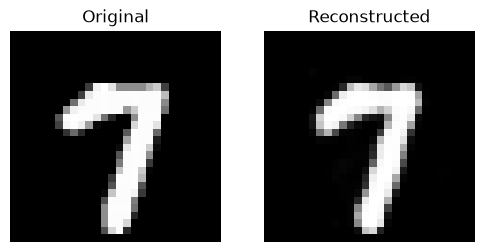

In [7]:
original = image.cpu().view(28, 28)

reconstructed = reconstruction.cpu().view(28, 28)

plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed")
plt.axis("off")

plt.show()